- Day 1: Learn State, Nodes, and Edges.
- Day 2: Build a chatbot graph.
- Day 3: Add tool calling (calculator or search).
- Day 4: Add conditional routing and loops.
- Day 5: Add memory and checkpoints.
- Day 6: Build a simple RAG agent.
- Day 7: Build a multi-agent project (planner, researcher, writer).

Imagine you're building an AI assistant.
With plain LLM calls:
```
User
  ↓
LLM
  ↓
Answer
```


With LangGraph:

```
User
  ↓
Planner
  ↓
Should I search?
  ├── Yes → Search Tool
  └── No
        ↓
Generate Answer
        ↓
Finish

```

# What is a State ?
State is a shared object that stores all information about your workflow .

Instead of passing 10 varivales between functions , every node reads from and writes to the same state .


Think of the state as a shared notebook .

```
State
{
    question
    messages
    documents
    answer
}


```


Without the state what we need to do ? 
Without State :

```
def search(question):
    ...

def summarize(question, docs):
    ...

def answer(question, docs, summary):
    ...
```

You keep passing the variable . 
With state .

```
def search(state):
    ...

def summarize(state):
    ...

def answer(state):
    ...

```

# Interview Problem ?

### Q. Why does LangGraph use state instead of function parameters?
Ans :
Because many nodes need access to the same information . A shared state simplifies data sharing , avoids long parameter lists , lets node communicate without being tightly coupled .

Key Takeaways
- State is shared memory for the workflow.
- Every node receives the current state.
- Every node returns only the updates it makes.
- LangGraph merges those updates automatically.
- Nodes communicate through state, not by calling each other.



In [6]:
# define a state 

from typing import TypedDict

class ChatState(TypedDict):
    question:str
    answer: str

"""
we define a state , using typedict , 
we defined that within the given state
we have question with type string 
and answer with type string 
"""

# write a node 

"""
every node:
- accepts 'state'
- returns a dictionary containing only updates 
"""


def generated_answer(state: ChatState):
    question = state["question"]

    return {
        "answer" : f"You asked :{question} , Just a suggestion ! Dont be oversmart !"
    }


state = {
    "question": "What is LangGraph?",
    "answer": ""
}

print("Before:" , state)

updates = generated_answer(state)

state.update(updates)# LangGraph does something similar internally
print("After:" , state)



Before: {'question': 'What is LangGraph?', 'answer': ''}
After: {'question': 'What is LangGraph?', 'answer': 'You asked :What is LangGraph? , Just a suggestion ! Dont be oversmart !'}


### What is a StateGraph?
A StateGraph is simply a blueprint of your workflow.
Think of it like Google Maps before you start driving.
It answers:
- What nodes exist?
- Where do we start?
- Where do we go next?
- When do we stop?

In [30]:
from typing import TypedDict
from langgraph.graph import StateGraph , START , END 
from langchain_text_splitters import CharacterTextSplitter

class ChatState(TypedDict):
    question: str
    answer: str 


def chatbot(state:ChatState):
    return{
        "answer" : f"Your question is : {state["question"]}"

    }

def make_uppercase(state:ChatState):
    return{
        "answer" : state["answer"].upper()
    }

graph = StateGraph(ChatState)

graph.add_node("chatbot" , chatbot)
graph.add_node("make_uppercase" , make_uppercase)
graph.add_edge(START, "chatbot" )
graph.add_edge("chatbot", "make_uppercase")
graph.add_edge("make_uppercase" , END)
app = graph.compile()

result = app.invoke({
    "question": "Hello!",
    "answer": ""
})

print(result)


{'question': 'Hello!', 'answer': 'YOUR QUESTION IS : HELLO!'}


# What the hell is an edge ?


edge answers a simple answer , what happens when we finish this node , where to go next


### normal edge 
suppose we have two nodes:

```
def search(state):
  ....

def answer(state):
  ....

```
-----


### connect them together 
```

graph.add_edge("search" , "answer" )


```



-----


# Now what if need decisions ?

We fucking need a conditional edge .


## The Router Function 
a router is just another python function. it looks at the state and returns where to go next 


```
def router(state):
  question = state("questions")
   
  if "calculate" in question:
      return "calculator


  return "chatbot" 
```

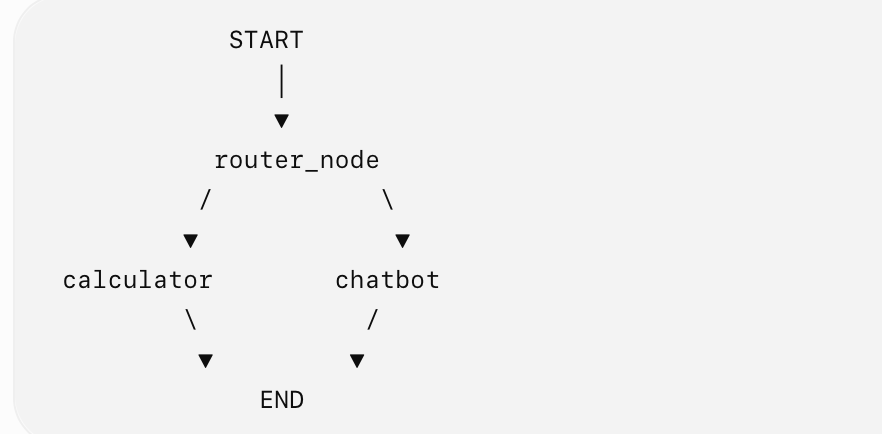

### registering it 

```
graph.add_node("router", router_node)
graph.add_node("calculator", calculator)
graph.add_node("chatbot", chatbot)
```

```
User
   │
   ▼
Understand Request
   │
   ▼
Need Search?
   │
 ┌─┴────────┐
 │          │
Yes         No
 │          │
 ▼          ▼
Search     LLM
 │          │
 └────┬─────┘
      ▼
Generate Code
      │
      ▼
Human Review
      │
 ┌────┴─────┐
 │          │
Reject    Approve
 │          │
 ▼          ▼
Retry      Run Tests
             │
             ▼
Save State (Persistence)
             │
             ▼
END



```

- ✅ State — shared data between nodes.
- ✅ StateGraph — defines the workflow.
- ✅ Nodes — units of work.
- ✅ Edges — fixed transitions.
- ✅ Conditional edges — dynamic routing.
- ✅ Tools — external capabilities invoked by the agent.
- ✅ Memory — state carried across interactions.
- ✅ Persistence — durable state and checkpointing.
- ✅ Human-in-the-loop — pause and resume with user approval.
